In [2]:
import os
import pickle
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from scipy.special import rel_entr
from matplotlib.ticker import MaxNLocator

from utils.helperfn import *
from utils.argconfig import *
from utils.decoderfn import *
from utils.mismatchfn import *
from utils.readalist import get_parity_check_alist

In [12]:
plt.style.use('bmh')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.facecolor': 'white',  # main axes background
    'figure.facecolor': 'white' # figure background
})

In [ ]:
# setting directory strings
resultsdir = os.path.join(os.getcwd(), "results")
maindec = "main_bec/mmc_results"
checksubr = "check_bec/mmc_results"
varsubr = "var_bec/mmc_results"

# loading simul parameters
with open(os.path.join(resultsdir, "main_bec/params_main.pkl"), "rb") as _file:
    _params = pickle.load(_file)

H = _params["H"]; m, n = H.shape
k = n - m
b = _params["barr"]
lmax = _params["lmax"]
dmax = max(_params["dvmax"], _params["dcmax"])
nprog = _params["nprog"]

In [5]:
# setting simul arrays
alpha_arr = np.arange(0.1, 1, 0.1)
eps_arr = np.arange(0.1, 1.0, 0.1)

### Figure 4 of JSAIT paper

In [ ]:
# reading pmmc results for each (\alpha, \epsilon) and saving total mmc
mmcMainUnif = np.zeros((len(alpha_arr), len(eps_arr)))

for jj, alpha in enumerate(alpha_arr):
    for ii, eps in enumerate(eps_arr):
        filepath = os.path.join(resultsdir, maindec, f"mmc_alpha_{alpha:.2f}_eps_{eps:.2f}.npz")
        mmcMainUnif[jj, ii] = np.sum(np.load(filepath)['mmc'])

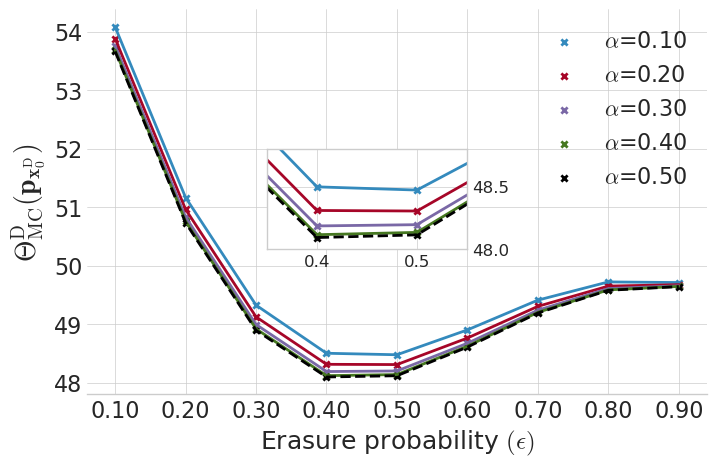

In [13]:
## Fig. 4a Mismatch cost as a fucntion of \epsilon

x = np.arange(len(eps_arr))

fig, ax1 = plt.subplots(figsize=(8,5))
# plotting \alpha \in {0.1, 0.2, 0.3, 0.4}
for jj in range(4):
    ax1.scatter(eps_arr, mmcMainUnif[jj, :], marker='x', s = 20, label = r"$\alpha$=%.2f"%(alpha_arr[jj]))
    ax1.plot(eps_arr, mmcMainUnif[jj, :])

# plotting \alpha = 0.5
ax1.scatter(eps_arr, mmcMainUnif[4, :], marker='x', color='k', s = 20, label = r"$\alpha$=%.2f"%(alpha_arr[4]))
ax1.plot(eps_arr, mmcMainUnif[4, :], 'k--')

ax1.set_xticks(eps_arr); ax1.set_xticklabels([f"{v:.2f}" for v in eps_arr])
ax1.set_xlabel(r'Erasure probability $(\epsilon)$', fontsize=18)
ax1.set_ylabel(r'$\Theta^{\mathrm{D}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}})$', fontsize=20)
ax1.legend(loc='upper right', fontsize=16, frameon=False)

# --- inset axes (top-left zoom) ---
axins = fig.add_axes([0.35, 0.4, 0.25, 0.2])  # [left, bottom, width, height]
for jj in range(4):
    axins.scatter(eps_arr, mmcMainUnif[jj, :], marker='x', s=20)
    axins.plot(eps_arr, mmcMainUnif[jj, :])

axins.scatter(eps_arr, mmcMainUnif[4, :], marker='x', color='k', s = 20)
axins.plot(eps_arr, mmcMainUnif[4, :], 'k--')

# zoom top of bars
axins.set_xlim(0.35, 0.55)
axins.set_ylim(48, 48.8)                # adjust so line touches tops of bars
axins.yaxis.set_ticks_position('right')

ax1.tick_params(axis='y', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)

for pos in ["right", "left", "top"]:
    ax1.spines[pos].set_visible(False)

plt.show()

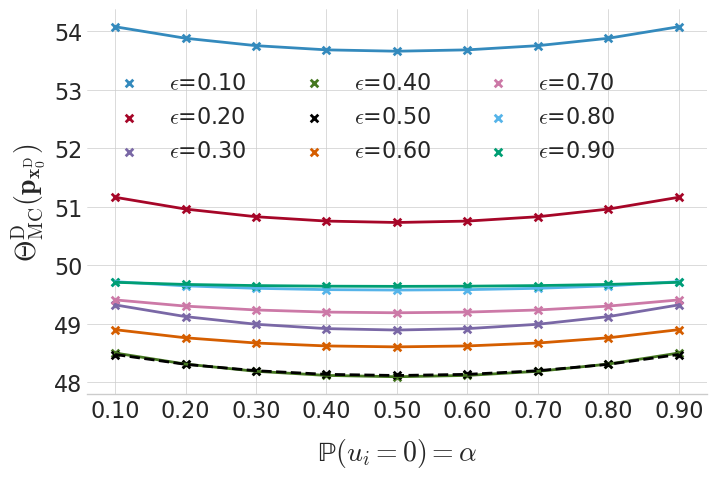

In [14]:
## Fig. 4b Mismatch cost as a fucntion of \alpha

x = np.arange(len(alpha_arr))

fig, ax1 = plt.subplots(figsize=(8,5))
# plotting \epsilon \in {0.1, 0.2, 0.3, 0.4}
for jj in range(4):
    ax1.scatter(alpha_arr, mmcMainUnif[:, jj], marker='x', s = 30, label = r"$\epsilon$=%.2f"%(eps_arr[jj]))
    ax1.plot(alpha_arr, mmcMainUnif[:, jj])

# plotting \epsilon = 0.5
ax1.scatter(alpha_arr, mmcMainUnif[:, 4], color='k', marker='x', s = 30, label = r"$\epsilon$=%.2f"%(eps_arr[4]))
ax1.plot(alpha_arr, mmcMainUnif[:, 4], 'k--')

# plotting \epsilon \in {0.6, 0.7, 0.8, 0.9}
for jj in range(5, 9):
    ax1.scatter(alpha_arr, mmcMainUnif[:, jj], marker='x', s = 30, label = r"$\epsilon$=%.2f"%(eps_arr[jj]))
    ax1.plot(alpha_arr, mmcMainUnif[:, jj])
    
ax1.set_xticks(alpha_arr); ax1.set_xticklabels([f"{v:.2f}" for v in alpha_arr])
ax1.set_xlabel(r'${\rm\mathbb{P}}(u_i = 0) = \alpha$', fontsize=20, labelpad=10)
ax1.set_ylabel(r'$\Theta^{\mathrm{D}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}})$', fontsize=20)
ax1.legend(loc='lower left', bbox_to_anchor=(0.0, 0.55), ncols=3, fontsize=16, frameon=False)

ax1.tick_params(axis='y', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)

for pos in ["right", "left", "top"]:
    ax1.spines[pos].set_visible(False)

plt.show()

### Figure 5 of JSAIT paper

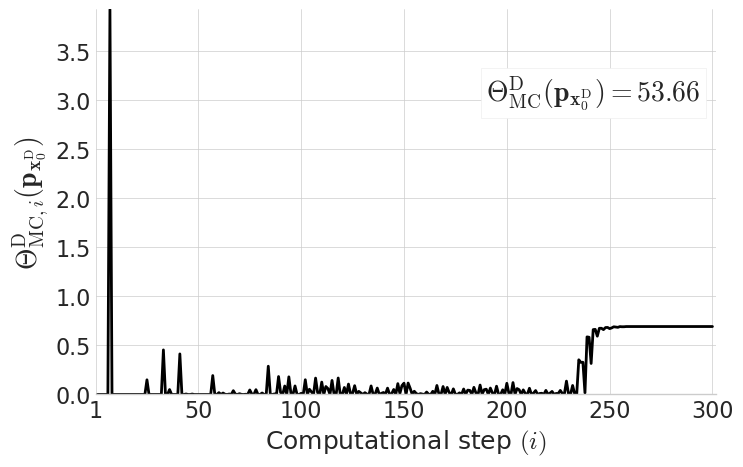

In [19]:
## Fig. 5a \epsilon=0.1
_alpha = 0.5; _epsilon = 0.1

# loading partial mmc results 
filepath = os.path.join(resultsdir, maindec, f"mmc_alpha_{_alpha:.2f}_eps_{_epsilon:.2f}.npz")
pmmc_a = np.load(filepath)['mmc']

# plotting 
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(pmmc_a) + 1), pmmc_a, 'k')
plt.text(190, 3, r"$\Theta^{\mathrm{D}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}}) = %.2f$"%np.sum(pmmc_a), fontsize=20, bbox=dict(facecolor='white'))
plt.tick_params(axis='y', labelsize=16)
plt.tick_params(axis='x', labelsize=16)
for pos in ["right", "left", "top"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\Theta^{\mathrm{D}}_{\mathrm{MC}, i}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}})$", fontsize=20); 
plt.ylim([0, max(pmmc_a)]); plt.xlim([0.5, len(pmmc_a) + 1.5])
plt.xticks(np.arange(0, len(pmmc_a) + 1, 50), [1] + list(np.arange(50, len(pmmc_a) + 1, 50)))
plt.xlabel(r"Computational step $(i)$", fontsize=18); 

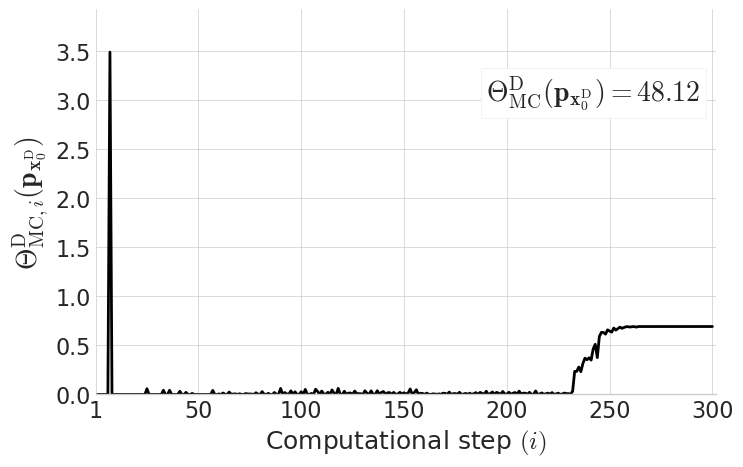

In [20]:
## Fig. 5b \epsilon=0.5
_alpha = 0.5; _epsilon = 0.5

# loading partial mmc results 
filepath = os.path.join(resultsdir, maindec, f"mmc_alpha_{_alpha:.2f}_eps_{_epsilon:.2f}.npz")
pmmc_b = np.load(filepath)['mmc']

# plotting 
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(pmmc_b) + 1), pmmc_b, 'k')
plt.text(190, 3, r"$\Theta^{\mathrm{D}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}}) = %.2f$"%np.sum(pmmc_b), fontsize=20, bbox=dict(facecolor='white'))
plt.tick_params(axis='y', labelsize=16)
plt.tick_params(axis='x', labelsize=16)
for pos in ["right", "left", "top"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\Theta^{\mathrm{D}}_{\mathrm{MC}, i}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}})$", fontsize=20); 
plt.ylim([0, max(pmmc_a)]); plt.xlim([0.5, len(pmmc_a) + 1.5])      # to keep same yticks for all three subplots, use the range of pmmc_a
plt.xticks(np.arange(0, len(pmmc_b) + 1, 50), [1] + list(np.arange(50, len(pmmc_b) + 1, 50)))
plt.xlabel(r"Computational step $(i)$", fontsize=18); 

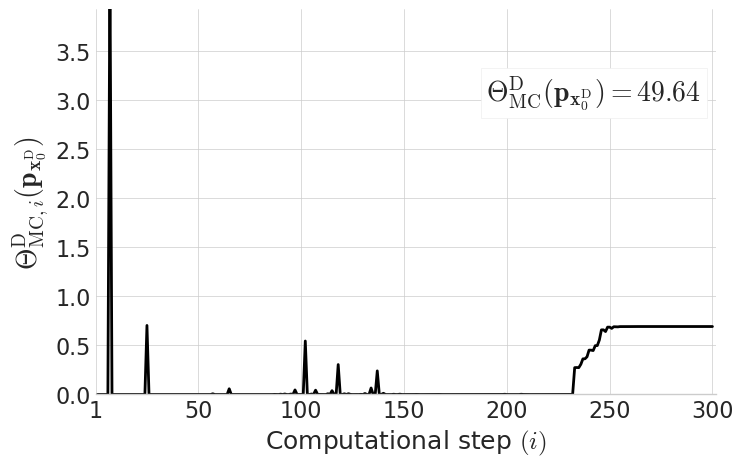

In [21]:
## Fig. 5c \epsilon=0.1
_alpha = 0.5; _epsilon = 0.9

# loading partial mmc results 
filepath = os.path.join(resultsdir, maindec, f"mmc_alpha_{_alpha:.2f}_eps_{_epsilon:.2f}.npz")
pmmc_c = np.load(filepath)['mmc']

# plotting 
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(pmmc_c) + 1), pmmc_c, 'k')
plt.text(190, 3, r"$\Theta^{\mathrm{D}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}}) = %.2f$"%np.sum(pmmc_c), fontsize=20, bbox=dict(facecolor='white'))
plt.tick_params(axis='y', labelsize=16)
plt.tick_params(axis='x', labelsize=16)
for pos in ["right", "left", "top"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\Theta^{\mathrm{D}}_{\mathrm{MC}, i}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}})$", fontsize=20); 
plt.ylim([0, max(pmmc_a)]); plt.xlim([0.5, len(pmmc_a) + 1.5])  # to keep same yticks for all three subplots, use the range of pmmc_a
plt.xticks(np.arange(0, len(pmmc_c) + 1, 50), [1] + list(np.arange(50, len(pmmc_c) + 1, 50)))
plt.xlabel(r"Computational step $(i)$", fontsize=18); 

### Figure 6 of JSAIT

In [ ]:
# reading pmmc values for check-to-var subroutine
filepath = os.path.join(resultsdir, checksubr, f"mmc_checksub.npz")
mmcCheckUnif = np.sum(np.load(filepath)['mmc'])     # total mmc for check-to-var subroutine

# reading pmmc values for var-to-check subroutine
filepath = os.path.join(resultsdir, checksubr, f"mmc_varsub.npz")
mmcVarUnif = np.sum(np.load(filepath)['mmc'])       # total mmc for var-to-check subroutine

# define total mmc of message-passing decoding process as per (19) in the paper
totalmmc = mmcMainUnif + lmax * (m * mmcCheckUnif + n * mmcVarUnif)

In [ ]:
## Fig. 6a Total mismatch cost of message-passing
x = np.arange(len(eps_arr))

fig, ax1 = plt.subplots(figsize=(8,5))
# plotting \alpha \in {0.1, 0.2, 0.3, 0.4}
for jj in range(4):
    ax1.scatter(eps_arr, totalmmc[jj, :], marker='x', s = 20, label = r"$\alpha$=%.2f"%(alpha_arr[jj]))
    ax1.plot(eps_arr, totalmmc[jj, :])

# plotting \alpha = 0.5
ax1.scatter(eps_arr, totalmmc[4, :], marker='x', color='k', s = 20, label = r"$\alpha$=%.2f"%(alpha_arr[4]))
ax1.plot(eps_arr, totalmmc[4, :], 'k--')

ax1.set_xticks(eps_arr); ax1.set_xticklabels([f"{v:.2f}" for v in eps_arr])
ax1.set_xlabel(r'Erasure probability $(\epsilon)$', fontsize=18)
ax1.set_ylabel(r'$\Theta^{\mathrm{Total}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}}, \mathbf{p}_{\mathbf{x}^{\mathrm{V}}_{0}}, \mathbf{p}_{\mathbf{x}^{\mathrm{C}}_{0}})$', fontsize=20)
ax1.legend(loc='upper right', fontsize=16, frameon=False)

# --- inset axes (top-left zoom) ---
axins = fig.add_axes([0.35, 0.4, 0.25, 0.2])  # [left, bottom, width, height]

# plot line on same axis as bars
for jj in range(5):
    axins.scatter(eps_arr, totalmmc[jj, :], marker='x', s=20)
    axins.plot(eps_arr, totalmmc[jj, :])

axins.scatter(eps_arr, totalmmc[4, :], marker='x', color='k', s = 20, label = r"$\alpha$=%.2f"%(alpha_arr[4]))
axins.plot(eps_arr, totalmmc[4, :], 'k--')

# zoom top of bars
axins.set_xlim(0.35, 0.55); axins.set_ylim(119.8, 120.8)  
axins.yaxis.set_ticks_position('right')

ax1.tick_params(axis='y', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)

for pos in ["right", "left", "top"]:
    ax1.spines[pos].set_visible(False)

plt.show()

In [ ]:
## Fig. 6b Decomposition of mismatch costs for \alpha=0.5

x = np.arange(len(eps_arr))
round1 = np.array([210, 208, 207.5, 207.2, 207.3, 207.6, 208, 209, 210])

fig, ax1 = plt.subplots(figsize=(8,5))

# stacked bars
ax1.bar(x, m * lmax * mmcCheckUnif, width=0.5, color='#0072B2')
ax1.bar(x, n * lmax * mmcVarUnif, width=0.5,
        bottom=m * lmax * mmcCheckUnif, color='#D55E00')

# choose row = 4 in mmcMainUnif array which corresponds to \alpha=0.5
ax1.bar(x, mmcMainUnif[4, :], width=0.5,
        bottom= lmax * (n * mmcVarUnif + m * mmcCheckUnif), color='#009E73')

ax1.set_ylabel(r'$\Theta^{\mathrm{D}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}}) + \ell_{\max} \left[m\cdot\Theta^{\mathrm{V}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{V}}_{0}}) + n\cdot\Theta^{\mathrm{C}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{C}}_{0}})\right]$', 
               fontsize=17)
ax1.set_xlabel(r"Erasure probability $(\epsilon)$", fontsize=18)
ax1.set_ylim(0, 126)
ax1.set_xticks(x)            # set tick positions
ax1.set_xticklabels([f"{v:.2f}" for v in eps_arr])  # set tick labels
ax1.legend([r"$m \cdot \Theta^{\mathrm{V}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{V}}_{0}})$", 
            r"$n \cdot \Theta^{\mathrm{C}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{C}}_{0}})$", 
            r"$\Theta^{\mathrm{D}}_{\mathrm{MC}}(\mathbf{p}_{\mathbf{x}^{\mathrm{D}}_{0}})$"], 
           loc='lower right', bbox_to_anchor=(1.3, -0.05), fontsize=16, frameon=False)
 
# --- inset axes (top-left zoom) ---
axins = fig.add_axes([0.6, 0.9, 0.45, 0.2])  # [left, bottom, width, height]

# stacked bars in inset
bottoms = m * lmax * mmcCheckUnif
bottoms += n * lmax * mmcVarUnif
axins.bar(x, m * lmax * mmcCheckUnif, width=0.5, color='#0072B2')
axins.bar(x, n * lmax * mmcVarUnif, width=0.5,
          bottom=m * mmcCheckUnif, color='#D55E00')

# choose row = 4 in mmcMainUnif array which corresponds to \alpha=0.5
axins.bar(x, mmcMainUnif[4, :], width=0.5, bottom=bottoms, color='#009E73')
axins.plot(x, totalmmc[4, :], 'ko-')    # plot line on same axis as bars

# zoom top of bars
axins.set_xlim(-0.5, len(x)-0.5)
axins.set_ylim(112, 130)  # adjust so line touches tops of bars
axins.yaxis.set_ticks_position('right')
axins.set_xticks([])

ax1.tick_params(axis='y', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)

for pos in ["right", "left", "top"]:
    ax1.spines[pos].set_visible(False)

plt.show()

### Figure 7 of JSAIT

In [ ]:
q0nonUnif = np.load(os.path.join(resultsdir, 'main_bec/q0_main.npz'))["q0_dist"]